In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2).zip


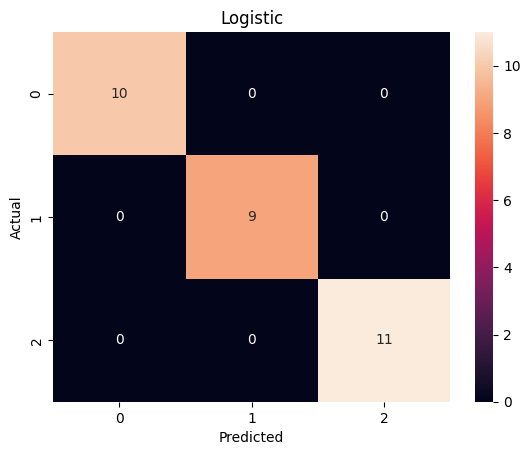

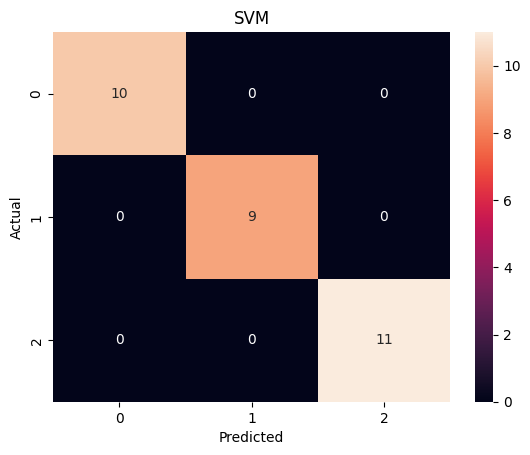

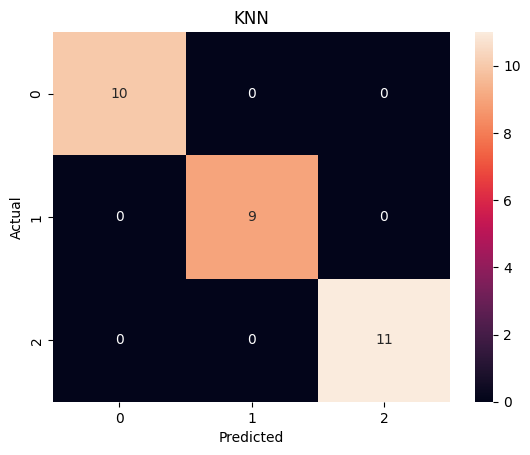

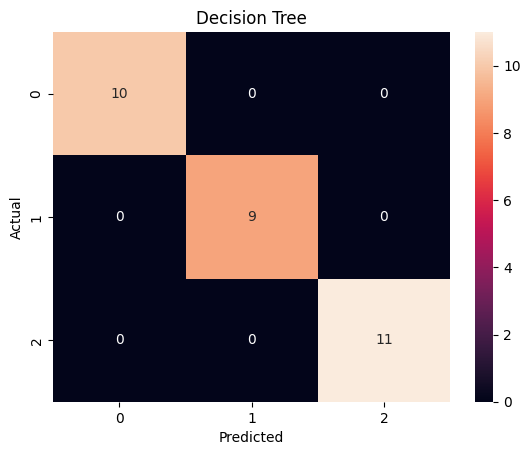

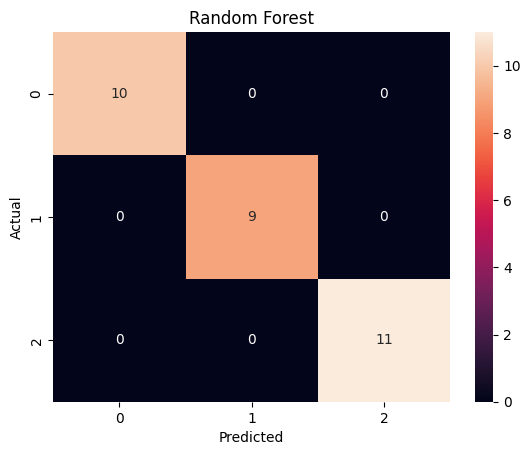


Model Comparison:
Logistic -> Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1: 1.00
SVM -> Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1: 1.00
KNN -> Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1: 1.00
Decision Tree -> Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1: 1.00
Random Forest -> Accuracy: 1.00, Precision: 1.00, Recall: 1.00, F1: 1.00


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Load dataset
X, y = load_iris(return_X_y=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models
models = {
    "Logistic": LogisticRegression(max_iter=200),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

results = {}

# Train + Evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[name] = [acc, prec, rec, f1]

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Comparison Table
print("\nModel Comparison:")
for name, vals in results.items():
    print(f"{name} -> Accuracy: {vals[0]:.2f}, Precision: {vals[1]:.2f}, Recall: {vals[2]:.2f}, F1: {vals[3]:.2f}")